# 03_cluster — Phân nhóm thị trường listing Airbnb

Notebook này thực hiện **Giai đoạn 2: phân nhóm thị trường** bằng K-means.

Mục tiêu là tạo các nhóm listing có đặc điểm tương đồng để so sánh giá công bằng hơn.  
`price` được giữ lại để phân tích sau khi có segment, nhưng **không được đưa vào K-means**.


In [2]:
from pathlib import Path
import ast
import warnings

import duckdb
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    import matplotlib
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DB_PATH = PROJECT_ROOT / "airbnb_analytics.duckdb"
OUTPUT_DIR = PROJECT_ROOT / "ml" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def save_csv_safely(df, path):
    """Lưu CSV; nếu file đang bị khóa thì lưu sang bản _new."""
    try:
        df.to_csv(path, index=False, encoding="utf-8")
        return path
    except PermissionError:
        fallback_path = path.with_name(f"{path.stem}_new{path.suffix}")
        df.to_csv(fallback_path, index=False, encoding="utf-8")
        print(f"File đang bị khóa, đã lưu bản thay thế: {fallback_path}")
        return fallback_path

DB_PATH, OUTPUT_DIR


(WindowsPath('d:/airbnb-analytics-platform/airbnb_analytics.duckdb'),
 WindowsPath('d:/airbnb-analytics-platform/ml/outputs'))

## 1. Đọc dữ liệu từ Silver

Notebook ưu tiên đọc `silver.silver_listings_cleaned`. Nếu bảng này không tồn tại thì đọc `silver.silver_listings`.


In [3]:
required_columns = [
    "listing_id",
    "price",
    "neighbourhood",
    "room_type",
    "property_type",
    "latitude",
    "longitude",
    "accommodates",
    "bedrooms",
    "bathrooms",
    "beds",
    "amenities",
    "minimum_nights",
    "number_of_reviews",
    "review_scores_rating",
    "host_is_superhost",
]

candidate_tables = ["silver.silver_listings_cleaned", "silver.silver_listings"]

with duckdb.connect(str(DB_PATH)) as con:
    available_tables = {
        f"{schema}.{table}"
        for schema, table in con.execute(
            """
            select table_schema, table_name
            from information_schema.tables
            where table_schema = 'silver'
            """
        ).fetchall()
    }

    source_table = next((table for table in candidate_tables if table in available_tables), None)
    if source_table is None:
        raise ValueError(f"Không tìm thấy bảng Silver phù hợp. Bảng hiện có: {sorted(available_tables)}")

    available_columns = {
        row[0]
        for row in con.execute(
            """
            select column_name
            from information_schema.columns
            where table_schema = ? and table_name = ?
            """,
            source_table.split("."),
        ).fetchall()
    }

    missing_columns = sorted(set(required_columns) - available_columns)
    if missing_columns:
        raise ValueError(f"Bảng {source_table} thiếu cột: {missing_columns}")

    query = f"select {', '.join(required_columns)} from {source_table}"
    listings_raw = con.execute(query).df()

print(f"Source table: {source_table}")
print(f"Shape: {listings_raw.shape}")
display(listings_raw.head())


Source table: silver.silver_listings_cleaned
Shape: (28806, 16)


,listing_id,price,neighbourhood,room_type,property_type,latitude,longitude,accommodates,bedrooms,bathrooms,beds,amenities,minimum_nights,number_of_reviews,review_scores_rating,host_is_superhost
0,105042,5600.0,Khlong Toei,Entire home/apt,Entire rental unit,13.73378,100.56303,5,3.0,3.5,3.0,"[""Bed linens"", ""Dryer"", ""Hot water"", ""Ethernet...",28,147,4.77,False
1,172332,1170.0,Bang Sue,Entire home/apt,Entire guesthouse,13.83148,100.52102,2,1.0,1.5,1.0,"[""Smoking allowed"", ""Hot water"", ""Gym"", ""Host ...",3,28,4.96,True
2,428950,810.0,Bang Kho laen,Entire home/apt,Entire rental unit,13.69800,100.52886,2,1.0,1.0,1.0,"[""Bed linens"", ""Dryer"", ""Hot water"", ""Shampoo""...",1,134,4.60,False
3,811670,2031.0,Din Daeng,Entire home/apt,Entire home,13.78499,100.56958,4,2.0,2.0,2.0,"[""Pets allowed"", ""Bed linens"", ""Smoking allowe...",3,31,4.50,False
4,1463101,NaN,Phaya Thai,Entire home/apt,Entire rental unit,13.78519,100.54960,2,1.0,1.0,NaN,"[""Essentials"", ""Free parking on premises"", ""Fi...",1,8,3.88,False


In [4]:
# Kiểm tra nhanh kiểu dữ liệu và missing value.
display(listings_raw.dtypes.to_frame("dtype"))

display(
    listings_raw[required_columns]
    .isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)


,dtype
listing_id,int64
price,float64
neighbourhood,str
room_type,str
property_type,str
latitude,float64
longitude,float64
accommodates,int32
bedrooms,float64
bathrooms,float64


,missing_count
review_scores_rating,10090
beds,5582
price,5533
host_is_superhost,1610
bedrooms,1304
bathrooms,151
neighbourhood,0
listing_id,0
accommodates,0
longitude,0


## 2. Lọc giá hợp lệ

`price` không dùng để tạo cluster. Tuy nhiên, giá cần được giữ lại để phân tích định giá sau khi đã có segment.


In [5]:
def clean_price(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.number)):
        return float(value)
    return pd.to_numeric(str(value).replace("$", "").replace(",", "").strip(), errors="coerce")

listings = listings_raw.copy()
listings["price"] = listings["price"].apply(clean_price)

before_rows = len(listings)
listings = listings.dropna(subset=["price"]).copy()
listings = listings[listings["price"] > 0].copy()
after_rows = len(listings)

# Dùng neighbourhood_cleansed làm tên chuẩn trong các bước phân tích sau.
listings["neighbourhood_cleansed"] = listings["neighbourhood"]

print(f"Rows before filtering price: {before_rows:,}")
print(f"Rows after filtering valid price: {after_rows:,}")
print(f"Removed rows: {before_rows - after_rows:,}")

display(listings[["listing_id", "price", "room_type", "property_type", "neighbourhood_cleansed"]].head())


Rows before filtering price: 28,806
Rows after filtering valid price: 23,273
Removed rows: 5,533


,listing_id,price,room_type,property_type,neighbourhood_cleansed
0,105042,5600.0,Entire home/apt,Entire rental unit,Khlong Toei
1,172332,1170.0,Entire home/apt,Entire guesthouse,Bang Sue
2,428950,810.0,Entire home/apt,Entire rental unit,Bang Kho laen
3,811670,2031.0,Entire home/apt,Entire home,Din Daeng
7,1887544,3735.0,Entire home/apt,Entire condo,Sathon


## 3. Gom nhóm `property_type`

`property_type` có nhiều giá trị nhỏ lẻ. Vì vậy notebook gom về các nhóm tài sản lớn hơn để K-means ổn định và dễ diễn giải.

Bản gom này có 9 nhóm chính, ví dụ: `Apartment / Condo`, `House / Home`, `Hotel / Resort`, `Villa`, `Niche / Special Stay`.


In [5]:
def group_property_type_for_model(value):
    """Gom property_type thành nhóm dùng cho K-means."""

    if pd.isna(value):
        return "Unspecified Property Type"

    text = str(value).lower().strip()

    # Các giá trị này không phải asset type rõ ràng vì thông tin private/entire đã nằm trong room_type.
    if text in ["private room", "entire place", "entire home/apt"]:
        return "Unspecified Property Type"

    if "serviced apartment" in text or "aparthotel" in text:
        return "Serviced Apartment / Aparthotel"

    if "hostel" in text:
        return "Hostel"

    if "guesthouse" in text or "bed and breakfast" in text:
        return "Guesthouse / B&B"

    if any(k in text for k in ["boutique hotel", "hotel", "resort", "ryokan", "kezhan"]):
        return "Hotel / Resort"

    if "villa" in text:
        return "Villa"

    # Loft được gộp vào Apartment / Condo vì thường là subtype của apartment.
    if any(k in text for k in ["rental unit", "condo", "apartment", "loft"]):
        return "Apartment / Condo"

    if any(k in text for k in [
        "townhouse",
        "guest suite",
        "vacation home",
        "casa particular",
        "bungalow",
        "cottage",
        "chalet",
        "entire home",
        "in home",
        "home/apt",
    ]):
        return "House / Home"

    # Tiny home, cabin, boat, treehouse... là nhóm niche/special vì số lượng ít và bản chất đặc thù.
    if any(k in text for k in [
        "tiny home",
        "treehouse",
        "earthen home",
        "dome",
        "tower",
        "lighthouse",
        "castle",
        "shipping container",
        "hut",
        "tent",
        "cabin",
        "nature lodge",
        "farm stay",
        "barn",
        "houseboat",
        "boat",
        "island",
        "camper/rv",
    ]):
        return "Niche / Special Stay"

    return "Unspecified Property Type"


listings["property_base_group"] = listings["property_type"].apply(group_property_type_for_model)

display(
    listings["property_base_group"]
    .value_counts()
    .to_frame("listing_count")
)


,listing_count
property_base_group,
Apartment / Condo,16911
House / Home,3061
Hotel / Resort,1565
Serviced Apartment / Aparthotel,640
Guesthouse / B&B,455
Hostel,361
Niche / Special Stay,118
Villa,97
Unspecified Property Type,65


## 4. Tạo `amenities_count` và `minimum_nights_log`

`amenities` là danh sách tiện nghi dạng text nên được chuyển thành số lượng tiện nghi.  
`minimum_nights` được log bằng `log1p` để giảm ảnh hưởng của các giá trị quá lớn khi chạy K-means.


In [6]:
def count_amenities(value):
    """Đếm số tiện nghi từ chuỗi amenities."""
    if pd.isna(value):
        return 0

    text = str(value).strip()
    if not text or text in ["[]", "{}"]:
        return 0

    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, (list, tuple, set)):
            return len(parsed)
    except (ValueError, SyntaxError):
        pass

    return len([item for item in text.strip("[]{}").split(",") if item.strip()])


listings["amenities_count"] = listings["amenities"].apply(count_amenities)
listings["minimum_nights_log"] = np.log1p(listings["minimum_nights"].clip(lower=0))

display(listings[["amenities", "amenities_count"]].head())
display(listings[["minimum_nights", "minimum_nights_log", "amenities_count"]].describe().T)


,amenities,amenities_count
0,"[""Bed linens"", ""Dryer"", ""Hot water"", ""Ethernet...",31
1,"[""Smoking allowed"", ""Hot water"", ""Gym"", ""Host ...",30
2,"[""Bed linens"", ""Dryer"", ""Hot water"", ""Shampoo""...",20
3,"[""Pets allowed"", ""Bed linens"", ""Smoking allowe...",40
7,"[""Paid crib - available upon request"", ""Free p...",48


,count,mean,std,min,25%,50%,75%,max
minimum_nights,23273.0,11.831436,31.090262,1.000000,1.000000,2.000000,14.00000,730.000000
minimum_nights_log,23273.0,1.654411,1.167189,0.693147,0.693147,1.098612,2.70805,6.594413
amenities_count,23273.0,27.082929,14.434207,0.000000,15.000000,26.000000,37.00000,95.000000


## 5. Xử lý missing value và biến phụ

Các biến review và host được giữ để phân tích sau cluster, **không đưa vào K-means**.

- `has_review`: dùng để biết listing đã có review hay chưa.
- `review_scores_rating`: giữ nguyên missing, không fill 0.
- `host_is_superhost`: chỉ dùng làm biến mô tả sau cluster.


In [7]:
missing_review_check = pd.DataFrame(
    {
        "metric": [
            "rating_null",
            "number_of_reviews_zero",
            "rating_null_and_zero_reviews",
            "rating_null_but_has_reviews",
        ],
        "count": [
            listings["review_scores_rating"].isna().sum(),
            (listings["number_of_reviews"].fillna(0) == 0).sum(),
            (listings["review_scores_rating"].isna() & (listings["number_of_reviews"].fillna(0) == 0)).sum(),
            (listings["review_scores_rating"].isna() & (listings["number_of_reviews"].fillna(0) > 0)).sum(),
        ],
    }
)
display(missing_review_check)

listings["has_review"] = (listings["number_of_reviews"].fillna(0) > 0).astype(int)

def to_binary(value):
    if pd.isna(value):
        return 0
    if isinstance(value, (bool, np.bool_)):
        return int(value)
    value = str(value).strip().lower()
    return 1 if value in ["t", "true", "1", "yes"] else 0

listings["host_is_superhost"] = listings["host_is_superhost"].apply(to_binary)

# Điền median theo room_type cho các biến quy mô phòng.
room_size_columns = ["bedrooms", "bathrooms", "beds"]
for column in room_size_columns:
    listings[column] = listings[column].fillna(listings.groupby("room_type")[column].transform("median"))
    listings[column] = listings[column].fillna(listings[column].median())

cluster_required_columns = [
    "room_type",
    "property_base_group",
    "accommodates",
    "bedrooms",
    "bathrooms",
    "beds",
    "amenities_count",
    "minimum_nights_log",
]

before_cluster_rows = len(listings)
listings = listings.dropna(subset=cluster_required_columns).copy()
after_cluster_rows = len(listings)

print(f"Rows before final clustering null filter: {before_cluster_rows:,}")
print(f"Rows after final clustering null filter: {after_cluster_rows:,}")

display(listings[cluster_required_columns].isna().sum().to_frame("missing_after_processing"))


,metric,count
0,rating_null,7158
1,number_of_reviews_zero,7158
2,rating_null_and_zero_reviews,7158
3,rating_null_but_has_reviews,0


Rows before final clustering null filter: 23,273
Rows after final clustering null filter: 23,273


,missing_after_processing
room_type,0
property_base_group,0
accommodates,0
bedrooms,0
bathrooms,0
beds,0
amenities_count,0
minimum_nights_log,0


## 6. Tạo feature matrix cho K-means

K-means chỉ dùng các biến mô tả bản chất listing:

- `room_type`
- `property_base_group`
- `accommodates`
- `bedrooms`
- `bathrooms`
- `beds`
- `amenities_count`
- `minimum_nights_log`

Không đưa vào K-means: `price`, `neighbourhood`, `latitude`, `longitude`, `review`, `has_review`, `host_is_superhost`.


In [8]:
categorical_features = ["room_type", "property_base_group"]

numeric_features = [
    "accommodates",
    "bedrooms",
    "bathrooms",
    "beds",
    "amenities_count",
    "minimum_nights_log",
]

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
    ],
    remainder="drop",
)

X_cluster = preprocessor.fit_transform(listings[categorical_features + numeric_features])
feature_names = preprocessor.get_feature_names_out()
X_cluster_df = pd.DataFrame(X_cluster, columns=feature_names, index=listings.index)

print(f"X_cluster shape: {X_cluster_df.shape}")
print(f"Missing values in X_cluster: {int(X_cluster_df.isna().sum().sum())}")
display(pd.DataFrame({"model_feature": X_cluster_df.columns}))


X_cluster shape: (23273, 19)
Missing values in X_cluster: 0


,model_feature
0,categorical__room_type_Entire home/apt
1,categorical__room_type_Hotel room
2,categorical__room_type_Private room
3,categorical__room_type_Shared room
4,categorical__property_base_group_Apartment / C...
5,categorical__property_base_group_Guesthouse / B&B
6,categorical__property_base_group_Hostel
7,categorical__property_base_group_Hotel / Resort
8,categorical__property_base_group_House / Home
9,categorical__property_base_group_Niche / Speci...


In [9]:
# Kiểm tra nhanh để đảm bảo các biến không dùng cho K-means không xuất hiện trong feature matrix.
for forbidden_column in [
    "price",
    "neighbourhood",
    "listing_id",
    "latitude",
    "longitude",
    "review",
    "has_review",
    "host",
]:
    matched_features = [column for column in X_cluster_df.columns if forbidden_column in column]
    print(f"Features containing '{forbidden_column}': {matched_features}")


Features containing 'price': []
Features containing 'neighbourhood': []
Features containing 'listing_id': []
Features containing 'latitude': []
Features containing 'longitude': []
Features containing 'review': []
Features containing 'has_review': []
Features containing 'host': []


## 7. Chọn số cụm K bằng Elbow

K-means cần chọn trước số cụm K. Notebook thử nhiều giá trị K và dùng Elbow để chọn mức K hợp lý.


,k,inertia
0,1,159968.112749
1,2,113348.138223
2,3,93785.955742
3,4,82514.529839
4,5,74004.193252
5,6,68275.048669
6,7,64157.615894
7,8,60170.878770
8,9,57403.761888
9,10,55179.870031


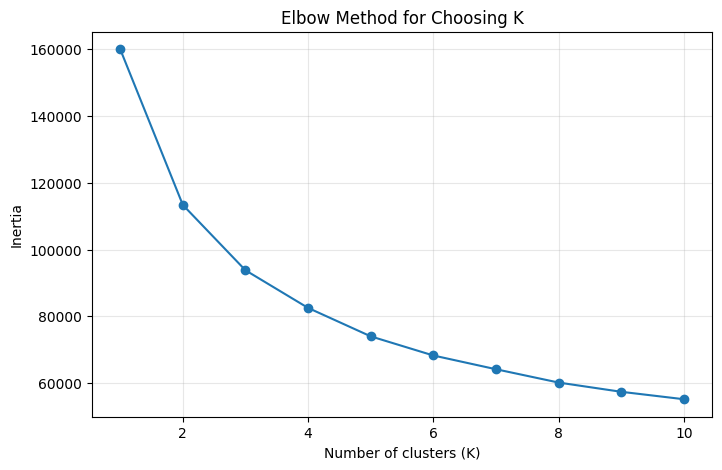

In [10]:
k_values = range(1, 11)
inertias = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=42,
    )
    kmeans.fit(X_cluster_df)
    inertias.append(kmeans.inertia_)

elbow_df = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
})

display(elbow_df)

plt.figure(figsize=(8, 5))
plt.plot(elbow_df["k"], elbow_df["inertia"], marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Choosing K")
plt.grid(True, alpha=0.3)
plt.show()


## 8. Chạy K-means final với K = 3

Dựa trên Elbow và khả năng diễn giải segment, notebook chọn `K = 3`.

`sklearn.KMeans` tự thực hiện các bước: khởi tạo centroid bằng k-means++, gán nhãn, cập nhật centroid và lặp đến khi hội tụ.


In [11]:
selected_k = 3

kmeans_final = KMeans(
    n_clusters=selected_k,
    init="k-means++",
    n_init=10,
    random_state=42,
)

listings["cluster"] = kmeans_final.fit_predict(X_cluster_df)

cluster_counts = (
    listings["cluster"]
    .value_counts()
    .sort_index()
    .to_frame("listing_count")
)

print("Final inertia:", kmeans_final.inertia_)
display(cluster_counts)


Final inertia: 93785.95574196214


,listing_count
cluster,
0,14039
1,7038
2,2196


## 9. Xuất dữ liệu sau clustering

File export gồm metadata gốc và feature matrix đã encode/scale để kiểm tra lại khi cần.  
Khi phân tích business, dùng các cột gốc, không dùng các cột `model_feature__...`.


In [12]:
cluster_metadata_columns = [
    "listing_id",
    "cluster",
    "price",
    "neighbourhood_cleansed",
    "room_type",
    "property_type",
    "property_base_group",
    "latitude",
    "longitude",
    "accommodates",
    "bedrooms",
    "bathrooms",
    "beds",
    "amenities",
    "amenities_count",
    "minimum_nights",
    "minimum_nights_log",
    "number_of_reviews",
    "review_scores_rating",
    "has_review",
    "host_is_superhost",
]

metadata_export = listings[cluster_metadata_columns].copy()

cluster_features_with_metadata = pd.concat(
    [
        metadata_export.reset_index(drop=True),
        X_cluster_df.reset_index(drop=True).add_prefix("model_feature__"),
    ],
    axis=1,
)

cluster_feature_path = OUTPUT_DIR / "cluster_features_with_metadata.csv"
cluster_feature_path = save_csv_safely(cluster_features_with_metadata, cluster_feature_path)

print(f"Saved cluster feature export: {cluster_feature_path}")
print(f"Shape: {cluster_features_with_metadata.shape}")
display(cluster_features_with_metadata.head())


Saved cluster feature export: d:\airbnb-analytics-platform\ml\outputs\cluster_features_with_metadata.csv
Shape: (23273, 40)


,listing_id,cluster,price,neighbourhood_cleansed,room_type,property_type,property_base_group,latitude,longitude,accommodates,bedrooms,bathrooms,beds,amenities,amenities_count,minimum_nights,minimum_nights_log,number_of_reviews,review_scores_rating,has_review,host_is_superhost,model_feature__categorical__room_type_Entire home/apt,model_feature__categorical__room_type_Hotel room,model_feature__categorical__room_type_Private room,model_feature__categorical__room_type_Shared room,model_feature__categorical__property_base_group_Apartment / Condo,model_feature__categorical__property_base_group_Guesthouse / B&B,model_feature__categorical__property_base_group_Hostel,model_feature__categorical__property_base_group_Hotel / Resort,model_feature__categorical__property_base_group_House / Home,model_feature__categorical__property_base_group_Niche / Special Stay,model_feature__categorical__property_base_group_Serviced Apartment / Aparthotel,model_feature__categorical__property_base_group_Unspecified Property Type,model_feature__categorical__property_base_group_Villa,model_feature__numeric__accommodates,model_feature__numeric__bedrooms,model_feature__numeric__bathrooms,model_feature__numeric__beds,model_feature__numeric__amenities_count,model_feature__numeric__minimum_nights_log
0,105042,1,5600.0,Khlong Toei,Entire home/apt,Entire rental unit,Apartment / Condo,13.73378,100.56303,5,3.0,3.5,3.0,"[""Bed linens"", ""Dryer"", ""Hot water"", ""Ethernet...",31,28,3.367296,147,4.77,1,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.755993,1.385820,2.013061,0.643975,0.271380,1.467561
1,172332,0,1170.0,Bang Sue,Entire home/apt,Entire guesthouse,Guesthouse / B&B,13.83148,100.52102,2,1.0,1.5,1.0,"[""Smoking allowed"", ""Hot water"", ""Gym"", ""Host ...",30,3,1.386294,28,4.96,1,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.515787,-0.339127,0.098101,-0.446799,0.202099,-0.229717
2,428950,0,810.0,Bang Kho laen,Entire home/apt,Entire rental unit,Apartment / Condo,13.69800,100.52886,2,1.0,1.0,1.0,"[""Bed linens"", ""Dryer"", ""Hot water"", ""Shampoo""...",20,1,0.693147,134,4.60,1,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.515787,-0.339127,-0.380639,-0.446799,-0.490715,-0.823590
3,811670,0,2031.0,Din Daeng,Entire home/apt,Entire home,House / Home,13.78499,100.56958,4,2.0,2.0,2.0,"[""Pets allowed"", ""Bed linens"", ""Smoking allowe...",40,3,1.386294,31,4.50,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.332067,0.523347,0.576841,0.098588,0.894912,-0.229717
4,1887544,0,3735.0,Sathon,Entire home/apt,Entire condo,Apartment / Condo,13.72096,100.52911,4,2.0,2.0,2.0,"[""Paid crib - available upon request"", ""Free p...",48,2,1.098612,163,4.90,1,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.332067,0.523347,0.576841,0.098588,1.449163,-0.476196


## 10. Phân tích core cluster

Bảng này chỉ dùng các biến đã tạo K-means để hiểu bản chất từng cluster.  
`price` chưa được dùng ở bước này.


In [13]:
core_features = [
    "cluster",
    "room_type",
    "property_base_group",
    "accommodates",
    "bedrooms",
    "bathrooms",
    "beds",
    "amenities_count",
    "minimum_nights",
]

cluster_eda_features = listings[core_features].copy()

def mode_value(series):
    counts = series.dropna().value_counts()
    return counts.index[0] if len(counts) else np.nan

def mode_pct(series):
    counts = series.dropna().value_counts()
    return counts.iloc[0] / counts.sum() if len(counts) else np.nan

cluster_profile = (
    cluster_eda_features
    .groupby("cluster")
    .agg(
        listing_count=("cluster", "size"),
        room_type_top=("room_type", mode_value),
        room_type_top_pct=("room_type", mode_pct),
        property_base_group_top=("property_base_group", mode_value),
        property_base_group_top_pct=("property_base_group", mode_pct),
        accommodates_mode=("accommodates", mode_value),
        accommodates_mode_pct=("accommodates", mode_pct),
        bedrooms_mode=("bedrooms", mode_value),
        bedrooms_mode_pct=("bedrooms", mode_pct),
        bathrooms_mode=("bathrooms", mode_value),
        bathrooms_mode_pct=("bathrooms", mode_pct),
        beds_mode=("beds", mode_value),
        beds_mode_pct=("beds", mode_pct),
        amenities_count_p25=("amenities_count", lambda x: x.quantile(0.25)),
        amenities_count_median=("amenities_count", "median"),
        amenities_count_p75=("amenities_count", lambda x: x.quantile(0.75)),
        minimum_nights_mode=("minimum_nights", mode_value),
        minimum_nights_mode_pct=("minimum_nights", mode_pct),
        minimum_nights_median=("minimum_nights", "median"),
    )
    .reset_index()
)

pct_cols = [col for col in cluster_profile.columns if col.endswith("_pct")]
cluster_profile[pct_cols] = cluster_profile[pct_cols].round(3)

display(cluster_profile)


,cluster,listing_count,room_type_top,room_type_top_pct,property_base_group_top,property_base_group_top_pct,accommodates_mode,accommodates_mode_pct,bedrooms_mode,bedrooms_mode_pct,bathrooms_mode,bathrooms_mode_pct,beds_mode,beds_mode_pct,amenities_count_p25,amenities_count_median,amenities_count_p75,minimum_nights_mode,minimum_nights_mode_pct,minimum_nights_median
0,0,14039,Entire home/apt,0.595,Apartment / Condo,0.675,2,0.602,1.0,0.786,1.0,0.801,1.0,0.646,13.0,22.0,33.0,1,0.623,1.0
1,1,7038,Entire home/apt,0.895,Apartment / Condo,0.973,2,0.681,1.0,0.784,1.0,0.803,1.0,0.699,18.0,31.0,42.0,30,0.306,28.0
2,2,2196,Entire home/apt,0.837,House / Home,0.561,6,0.237,3.0,0.418,3.0,0.234,4.0,0.256,19.0,32.0,43.0,1,0.625,1.0


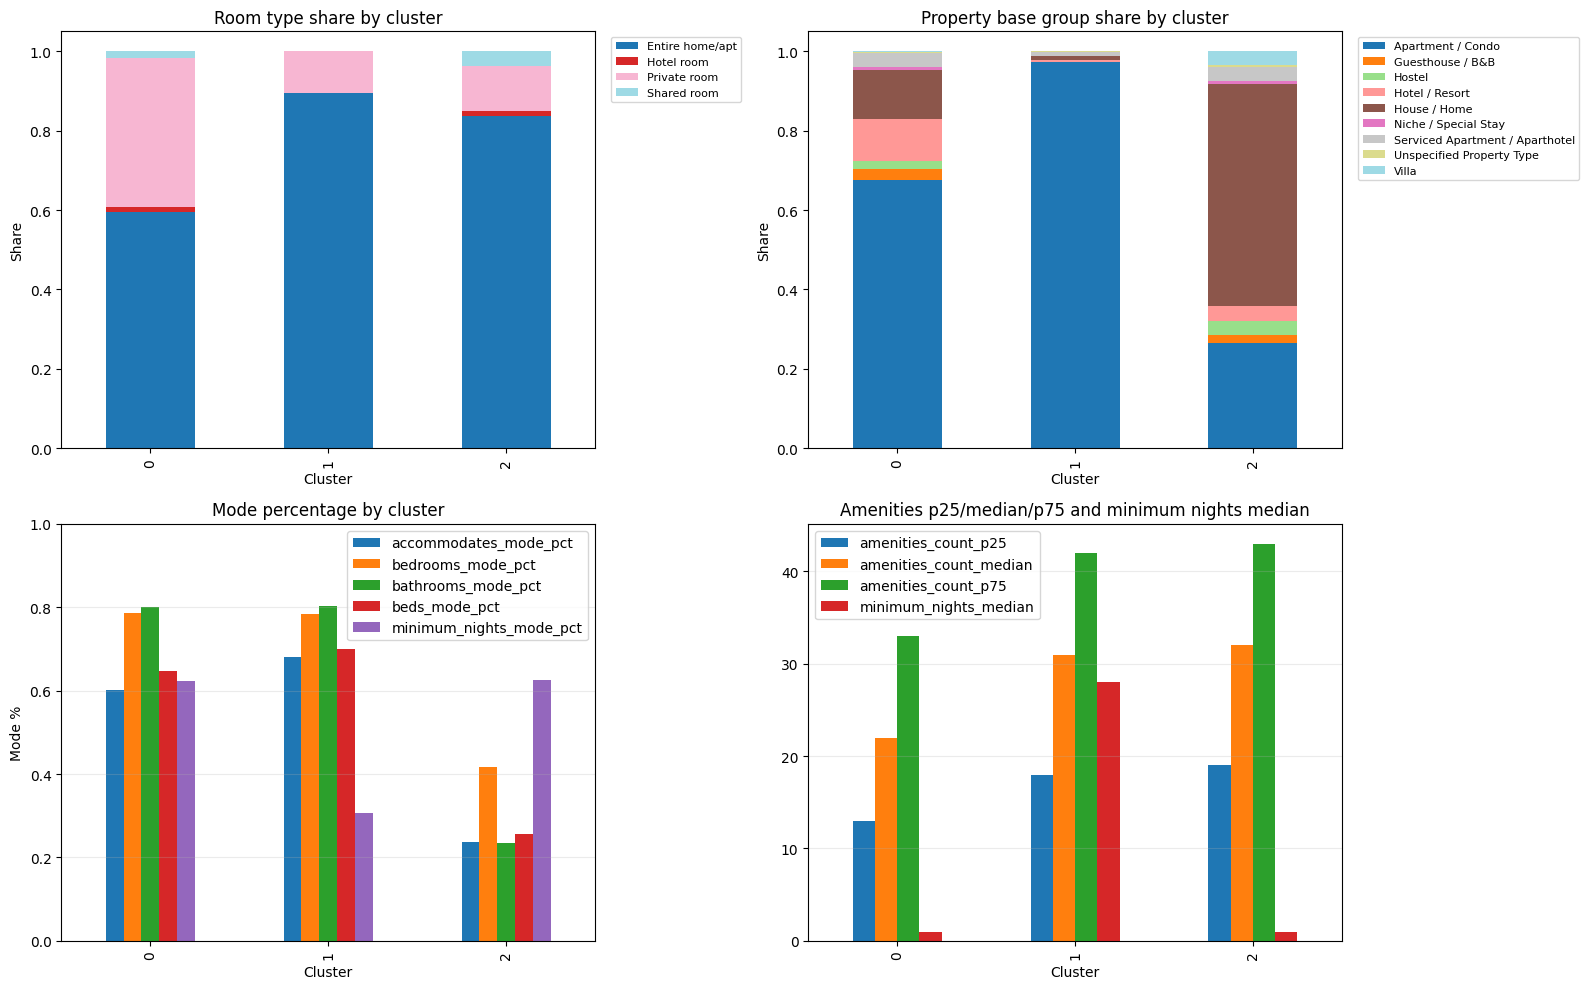

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

room_dist = pd.crosstab(cluster_eda_features["cluster"], cluster_eda_features["room_type"], normalize="index")
room_dist.plot(kind="bar", stacked=True, ax=axes[0, 0], colormap="tab20")
axes[0, 0].set_title("Room type share by cluster")
axes[0, 0].set_xlabel("Cluster")
axes[0, 0].set_ylabel("Share")
axes[0, 0].legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")

property_dist = pd.crosstab(cluster_eda_features["cluster"], cluster_eda_features["property_base_group"], normalize="index")
property_dist.plot(kind="bar", stacked=True, ax=axes[0, 1], colormap="tab20")
axes[0, 1].set_title("Property base group share by cluster")
axes[0, 1].set_xlabel("Cluster")
axes[0, 1].set_ylabel("Share")
axes[0, 1].legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")

mode_pct_cols = [
    "accommodates_mode_pct",
    "bedrooms_mode_pct",
    "bathrooms_mode_pct",
    "beds_mode_pct",
    "minimum_nights_mode_pct",
]
cluster_profile.plot(x="cluster", y=mode_pct_cols, kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Mode percentage by cluster")
axes[1, 0].set_xlabel("Cluster")
axes[1, 0].set_ylabel("Mode %")
axes[1, 0].set_ylim(0, 1)
axes[1, 0].grid(axis="y", alpha=0.25)

cluster_profile.plot(
    x="cluster",
    y=["amenities_count_p25", "amenities_count_median", "amenities_count_p75", "minimum_nights_median"],
    kind="bar",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Amenities p25/median/p75 and minimum nights median")
axes[1, 1].set_xlabel("Cluster")
axes[1, 1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


## 11. Nhận xét core cluster và đặt tên segment

- **Cluster 0**: cụm lớn nhất. `room_type` chủ yếu là `Entire home/apt` nhưng chưa áp đảo tuyệt đối, `property_base_group` chủ yếu là `Apartment / Condo`. Listing phổ biến là 2 khách, 1 phòng ngủ, 1 phòng tắm, 1 giường. Tiện nghi ở mức vừa và `minimum_nights` chủ yếu là 1 đêm.  
  → **Segment: Standard short-stay listings**

- **Cluster 1**: chủ yếu là `Entire home/apt` và gần như toàn bộ là `Apartment / Condo`. Quy mô vẫn là listing nhỏ cho 2 khách, 1 phòng ngủ, 1 phòng tắm, 1 giường. Điểm khác biệt chính là `minimum_nights` cao, thiên về lưu trú dài ngày.  
  → **Segment: Long-stay standard apartments**

- **Cluster 2**: chủ yếu là `Entire home/apt`, trong đó `House / Home` chiếm tỷ trọng cao nhất. Quy mô lớn hơn rõ rệt với nhiều khách, nhiều phòng ngủ và nhiều giường hơn. `minimum_nights` chủ yếu là 1 đêm.  
  → **Segment: Large short-stay group homes**


## 12. Gắn tên segment


In [16]:
segment_map = {
    0: "Standard short-stay listings",
    1: "Long-stay standard apartments",
    2: "Large short-stay group homes",
}

listings["segment_name"] = listings["cluster"].map(segment_map).fillna("Unknown")
cluster_features_with_metadata["segment_name"] = cluster_features_with_metadata["cluster"].map(segment_map).fillna("Unknown")

cluster_listing_path = OUTPUT_DIR / "cluster_listing.csv"
cluster_listing_path = save_csv_safely(cluster_features_with_metadata, cluster_listing_path)

print(f"Saved cluster listing: {cluster_listing_path}")
display(listings[["listing_id", "cluster", "segment_name"]].head())


Saved cluster listing: d:\airbnb-analytics-platform\ml\outputs\cluster_listing.csv


,listing_id,cluster,segment_name
0,105042,1,Long-stay standard apartments
1,172332,0,Standard short-stay listings
2,428950,0,Standard short-stay listings
3,811670,0,Standard short-stay listings
7,1887544,0,Standard short-stay listings


## 13. Phân tích price


In [8]:
# Cell 1: Doc cluster_listing va tong hop gia theo cluster
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "ml" / "outputs"

cluster_listing_df = pd.read_csv(OUTPUT_DIR / "cluster_listing.csv")

cluster_price_summary = (
    cluster_listing_df
    .groupby(["cluster", "segment_name"], dropna=False)
    .agg(
        listing_count=("listing_id", "count"),
        median_price=("price", "median"),
        p25_price=("price", lambda x: x.quantile(0.25)),
        p75_price=("price", lambda x: x.quantile(0.75)),
        mean_price=("price", "mean"),
    )
    .reset_index()
    .sort_values("cluster")
)

cluster_price_summary


,cluster,segment_name,listing_count,median_price,p25_price,p75_price,mean_price
0,0,Standard short-stay listings,14039,1324.0,900.00,2000.00,2206.036327
1,1,Long-stay standard apartments,7038,1274.0,903.00,1798.00,1943.066780
2,2,Large short-stay group homes,2196,4251.0,2631.75,6823.75,6468.912113


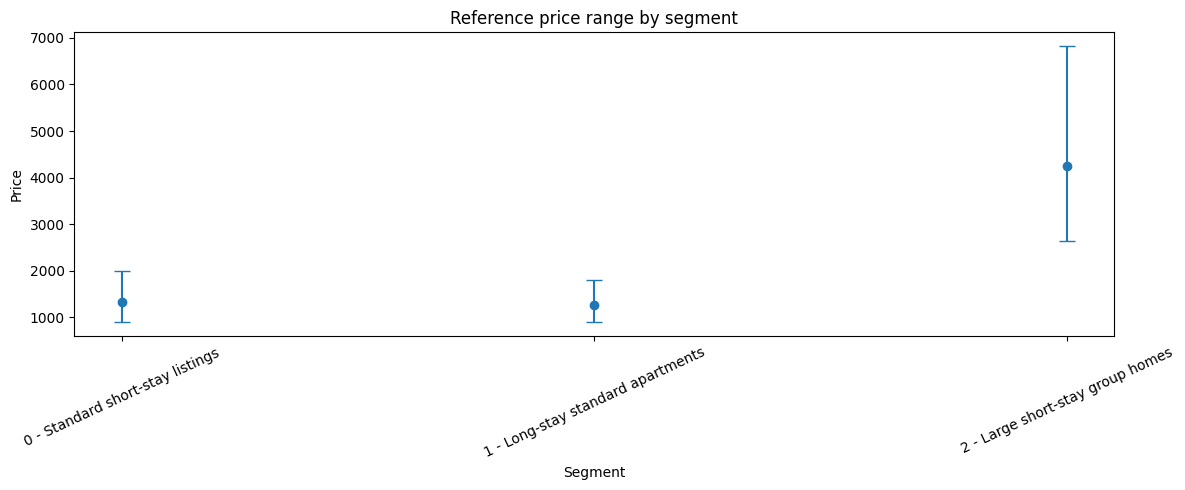

In [10]:
# Visualize reference price by segment
plot_df = cluster_price_summary.copy()
plot_df["cluster_label"] = (
    plot_df["cluster"].astype(str)
    + " - "
    + plot_df["segment_name"].astype(str)
)

yerr = [
    plot_df["median_price"] - plot_df["p25_price"],
    plot_df["p75_price"] - plot_df["median_price"],
]

plt.figure(figsize=(12, 5))

plt.errorbar(
    plot_df["cluster_label"],
    plot_df["median_price"],
    yerr=yerr,
    fmt="o",
    capsize=6
)

plt.title("Reference price range by segment")
plt.xlabel("Segment")
plt.ylabel("Price")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

- Standard short-stay listings: có median price khoảng 1,300. Khoảng giá phổ biến dao động khoảng 900–2,000 => phân khúc listing tiêu chuẩn ngắn ngày với mặt bằng giá trung bình. Phần lớn listing trong nhóm này nằm quanh mức giá thấp đến trung bình, phù hợp với các listing quy mô nhỏ, lưu trú ngắn ngày.
- Long-stay standard apartments: có median price khoảng 1,200–1,300, khá gần với Cluster 0. Khoảng giá phổ biến cũng tương tự, khoảng 900–1,800 => nhóm căn hộ tiêu chuẩn dài ngày không có mặt bằng giá cao hơn rõ rệt so với nhóm short-stay tiêu chuẩn. Khác biệt chính của Cluster 1 không nằm ở giá, mà nằm ở đặc điểm lưu trú dài ngày, đặc biệt là minimum nights cao hơn.
- Large short-stay group homes: có median price cao nhất, khoảng 4,200. Khoảng giá phổ biến rộng hơn nhiều, khoảng 2,600–6,800, khoảng p25–p75 rộng cho thấy giá trong nhóm này phân hóa mạnh => Một số listing có thể chỉ ở mức large home phổ thông, trong khi một số listing khác có thể là nhà lớn, villa hoặc listing cao cấp hơn.

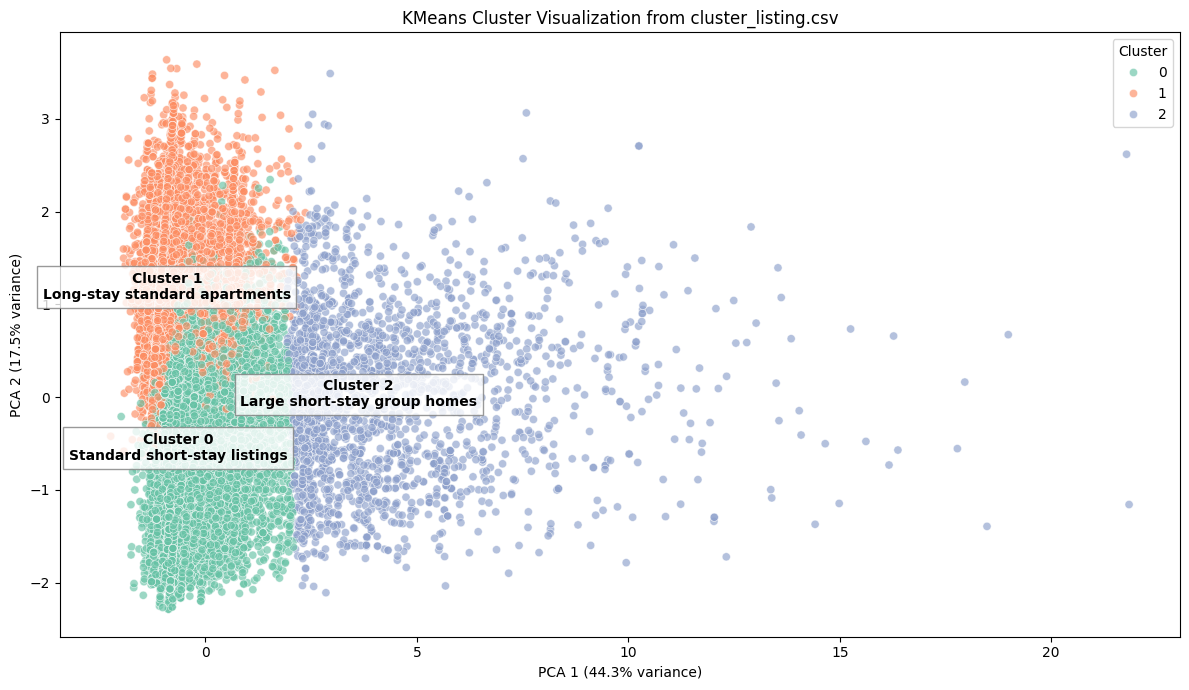

In [5]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "ml" / "outputs"

cluster_listing_df = pd.read_csv(OUTPUT_DIR / "cluster_listing.csv")

model_feature_cols = [
    col for col in cluster_listing_df.columns
    if col.startswith("model_feature__")
]

X_cluster_vis = cluster_listing_df[model_feature_cols].copy()

pca = PCA(n_components=2, random_state=42)
pca_points = pca.fit_transform(X_cluster_vis)

cluster_vis_df = cluster_listing_df[
    ["listing_id", "cluster", "segment_name", "price"]
].copy()

cluster_vis_df["pca_1"] = pca_points[:, 0]
cluster_vis_df["pca_2"] = pca_points[:, 1]

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=cluster_vis_df,
    x="pca_1",
    y="pca_2",
    hue="cluster",
    palette="Set2",
    alpha=0.65,
    s=35,
)

for cluster_id, group in cluster_vis_df.groupby("cluster"):
    center_x = group["pca_1"].median()
    center_y = group["pca_2"].median()
    segment = group["segment_name"].mode().iloc[0]

    plt.text(
        center_x,
        center_y,
        f"Cluster {cluster_id}\n{segment}",
        fontsize=10,
        weight="bold",
        ha="center",
        va="center",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
    )

plt.title("KMeans Cluster Visualization from cluster_listing.csv")
plt.xlabel(f"PCA 1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PCA 2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()